Attrition Rate by Department:
Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: AttritionFlag, dtype: float64

Attrition Rate by Age Group:
AgeGroup
18-30    25.396825
31-40    13.731826
41-50    10.559006
51-60    12.587413
Name: AttritionFlag, dtype: float64

Attrition Rate by Gender:
Gender
Female    14.795918
Male      17.006803
Name: AttritionFlag, dtype: float64

Mean Monthly Income by Attrition:
Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

Mean Years at Company by Attrition:
Attrition
No     7.369019
Yes    5.130802
Name: YearsAtCompany, dtype: float64


C:\Users\harsh\AppData\Local\Temp\ipykernel_20996\203810942.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('AgeGroup')['AttritionFlag'].mean()*100)


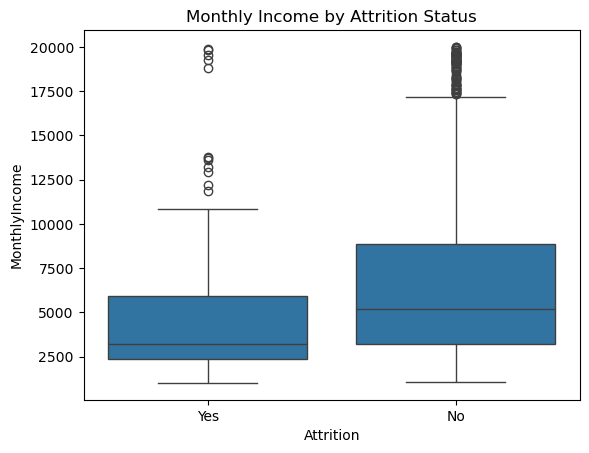

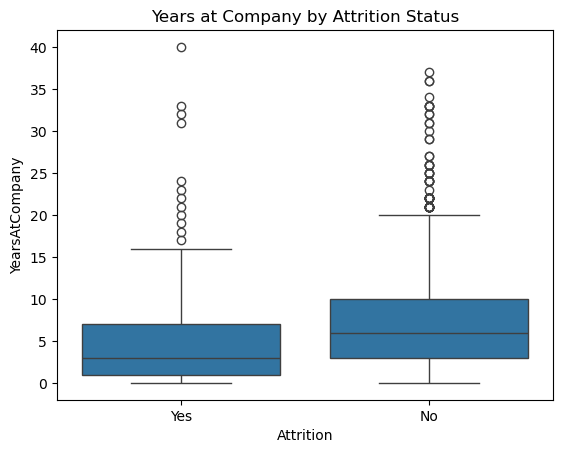

Chi-square test p-value for Department vs Attrition: 0.0045
Chi-square test p-value for Gender vs Attrition: 0.2906
T-test p-value for income difference: 0.0000

Correlation matrix:
                      Age  MonthlyIncome  YearsAtCompany  JobSatisfaction  \
Age              1.000000       0.497855        0.311309        -0.004892   
MonthlyIncome    0.497855       1.000000        0.514285        -0.007157   
YearsAtCompany   0.311309       0.514285        1.000000        -0.003803   
JobSatisfaction -0.004892      -0.007157       -0.003803         1.000000   
AttritionFlag   -0.159205      -0.159840       -0.134392        -0.103481   

                 AttritionFlag  
Age                  -0.159205  
MonthlyIncome        -0.159840  
YearsAtCompany       -0.134392  
JobSatisfaction      -0.103481  
AttritionFlag         1.000000  


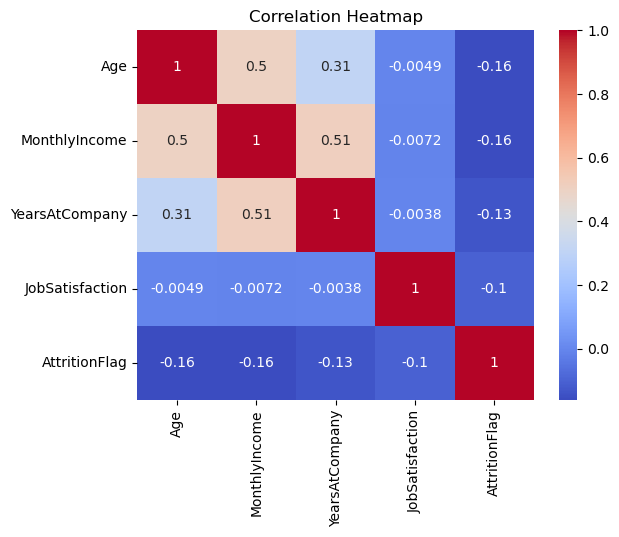

Optimization terminated successfully.
         Current function value: 0.388455
         Iterations 7

Logistic Regression Summary:
                           Logit Regression Results                           
Dep. Variable:          AttritionFlag   No. Observations:                 1470
Model:                          Logit   Df Residuals:                     1465
Method:                           MLE   Df Model:                            4
Date:                Sat, 01 Aug 2026   Pseudo R-squ.:                  0.1205
Time:                        00:03:49   Log-Likelihood:                -571.03
converged:                       True   LL-Null:                       -649.29
Covariance Type:            nonrobust   LLR p-value:                 8.132e-33
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.5133      0.230     -2.230      0.026      -0.

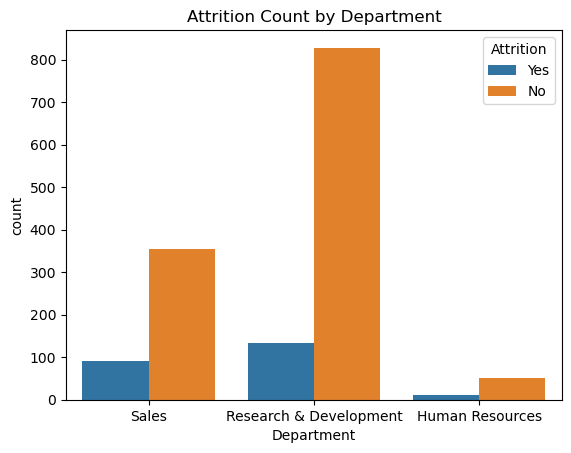

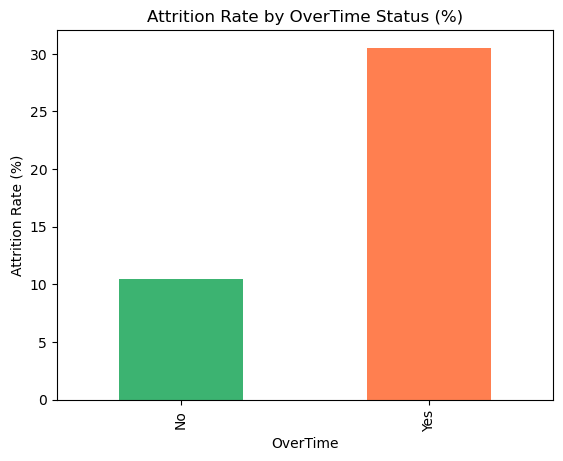

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind
import statsmodels.formula.api as smf

# Load dataset (update file path)
df = pd.read_csv("HR Employee Attrition.csv")

# Convert Attrition to binary flag for modeling
df['AttritionFlag'] = df['Attrition'].map({'Yes':1, 'No':0})

# Add Age Groups for analysis
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,30,40,50,60], labels=['18-30','31-40','41-50','51-60'])

# -----------------------------
# Descriptive Stats
# -----------------------------
print("Attrition Rate by Department:")
print(df.groupby('Department')['AttritionFlag'].mean()*100)

print("\nAttrition Rate by Age Group:")
print(df.groupby('AgeGroup')['AttritionFlag'].mean()*100)

print("\nAttrition Rate by Gender:")
print(df.groupby('Gender')['AttritionFlag'].mean()*100)

print("\nMean Monthly Income by Attrition:")
print(df.groupby('Attrition')['MonthlyIncome'].mean())

print("\nMean Years at Company by Attrition:")
print(df.groupby('Attrition')['YearsAtCompany'].mean())

# Boxplots for Monthly Income and YearsAtCompany by Attrition
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Monthly Income by Attrition Status')
plt.show()

sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title('Years at Company by Attrition Status')
plt.show()

# -----------------------------
# Probability / Hypothesis Testing
# -----------------------------
# Chi-square test for Dept vs Attrition
for var in ['Department', 'Gender']:
    ct = pd.crosstab(df[var], df['Attrition'])
    chi2, p, dof, ex = chi2_contingency(ct)
    print(f"Chi-square test p-value for {var} vs Attrition: {p:.4f}")

# T-test for Monthly Income difference by Attrition
left_income = df.loc[df['Attrition'] == 'Yes', 'MonthlyIncome']
stay_income = df.loc[df['Attrition'] == 'No', 'MonthlyIncome']
t_stat, p_val = ttest_ind(left_income, stay_income)
print(f"T-test p-value for income difference: {p_val:.4f}")

# -----------------------------
# Correlation Analysis
# -----------------------------
corr_matrix = df[['Age','MonthlyIncome','YearsAtCompany','JobSatisfaction','AttritionFlag']].corr()
print("\nCorrelation matrix:")
print(corr_matrix)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# Regression (Logistic Regression)
# -----------------------------
df['OverTimeFlag'] = (df['OverTime'] == 'Yes').astype(int)

model = smf.logit('AttritionFlag ~ JobSatisfaction + OverTimeFlag + MonthlyIncome + YearsAtCompany', data=df).fit()
print("\nLogistic Regression Summary:")
print(model.summary())

print("\nOdds Ratios:")
print(np.exp(model.params))

# -----------------------------
# Graphical Analysis
# -----------------------------
sns.countplot(x='Department', hue='Attrition', data=df)
plt.title("Attrition Count by Department")
plt.show()

attrition_overtime = df.groupby('OverTime')['AttritionFlag'].mean()*100
attrition_overtime.plot(kind='bar', color=['mediumseagreen','coral'])
plt.title("Attrition Rate by OverTime Status (%)")
plt.ylabel("Attrition Rate (%)")
plt.show()
